# TP1 — EDA & Nettoyage du dataset Lumina & Co

**Objectif de la journée :** comprendre les données livrées par le CRM (`customers.csv`, `transactions.csv`), documenter leurs problèmes, les traiter de façon justifiée, puis conduire une EDA orientée marketing pour poser les hypothèses qui structureront la segmentation RFM du Jour 2.

Plan :
1. Chargement & diagnostic
2. Détection et traitement des anomalies
3. EDA orientée marketing
4. Hypothèses marketing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = "Lumina & Co - CRM"


## Étape 1 — Chargement

On charge les deux fichiers *tels quels*, sans rien corriger, et on documente ce qu'on observe.


In [2]:
customers_raw = pd.read_csv(f"{DATA_DIR}/customers.csv")
transactions_raw = pd.read_csv(f"{DATA_DIR}/transactions.csv")

print("customers.csv    :", customers_raw.shape)
print("transactions.csv :", transactions_raw.shape)
customers_raw.head()


customers.csv    : (50295, 13)
transactions.csv : (1613433, 9)


,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,declared_preference,age_bracket,life_stage,urban_density
0,56396,France,2026-05-18 00:00:00,2026-06-11 00:00:00,1,757.68,757.68,19,24,NaN,NaN,NaN,Zone urbaine dense
1,14297,France,2025-09-28 19:41:00,2026-06-12 20:16:00,4,"2,325.35",581.34,17,274,NaN,NaN,NaN,NaN
2,34160,France,2024-03-25 00:00:00,2025-06-03 00:00:00,1,519.12,519.12,392,435,Peau sèche,45-54 ans,NaN,NaN
3,61352,France,2023-06-21 00:00:00,2025-03-02 00:00:00,4,"6,394.33","1,598.58",485,620,Peau sèche,35-44 ans,Jeune actif en solo,NaN
4,20612,France,2025-09-19 00:00:00,2026-06-17 00:00:00,9,"5,918.34",657.59,13,271,NaN,NaN,NaN,NaN


In [3]:
transactions_raw.head()


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
0,509453,"13,381.00",82583,Savon Surgras Lavande,Corps,3,7.72,2024-12-12 20:59:00,France
1,558926,"17,469.00",23201,Lait Corps Amande Douce,Corps,1,18.21,2026-01-23 21:31:00,France
2,567853,"15,484.00",23289,Savon Surgras Lavande,Corps,1,7.53,2026-04-13 00:41:00,France
3,549949,"13,208.00",22289,Huile Démaquillante Camélia,Visage,1,22.84,2025-11-02 00:07:00,France
4,505081,"16,742.00",22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.12,2024-11-08 20:59:00,France


### Combien de clients / transactions / sur quelle période ?

In [4]:
transactions_raw['invoice_date'] = pd.to_datetime(transactions_raw['invoice_date'])

n_customers = customers_raw['customer_id'].nunique()
n_transactions = len(transactions_raw)
n_invoices = transactions_raw['invoice_id'].nunique()
period_start = transactions_raw['invoice_date'].min()
period_end = transactions_raw['invoice_date'].max()

print(f"Clients (profils CRM)          : {n_customers:,}")
print(f"Lignes de transaction           : {n_transactions:,}")
print(f"Factures (invoice_id) distinctes: {n_invoices:,}")
print(f"Période couverte                : {period_start.date()} -> {period_end.date()} "
      f"({(period_end - period_start).days} jours, ~{(period_end - period_start).days/365:.1f} ans)")


Clients (profils CRM)          : 50,295
Lignes de transaction           : 1,613,433
Factures (invoice_id) distinctes: 247,690
Période couverte                : 2022-01-07 -> 2026-06-30 (1635 jours, ~4.5 ans)


### Valeurs manquantes

In [5]:
def missing_report(df, name):
    rep = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean()*100).round(2)
    })
    rep = rep[rep['n_missing'] > 0].sort_values('pct_missing', ascending=False)
    print(f"--- {name} ---")
    print(rep if len(rep) else "Aucune valeur manquante.")
    print()

missing_report(customers_raw, "customers.csv")
missing_report(transactions_raw, "transactions.csv")


--- customers.csv ---
                     n_missing  pct_missing
urban_density            40332        80.19
life_stage               38986        77.51
declared_preference      31108        61.85
age_bracket              28821        57.30



--- transactions.csv ---
              n_missing  pct_missing
customer_id      367328        22.77
product_name       2241         0.14



### Types de données attendus vs observés

| Colonne | Type attendu | Type observé | Remarque |
|---|---|---|---|
| `customers.first_purchase` / `last_purchase` | datetime | `object` (string) | à convertir |
| `customers.n_orders` | int | `int64` | OK |
| `customers.total_spent` / `avg_basket` | float | `float64` | OK |
| `transactions.customer_id` | int (identifiant) | `float64` | passé en float à cause des NaN — signal en soi |
| `transactions.invoice_date` | datetime | `object` (string) | à convertir |
| `transactions.product_code` | catégoriel (string) | `object` mais mélange codes produits (`85099C`) et codes non-produits (`POST`, `BANK CHARGES`, `S`, `M`, `D`...) | voir Étape 2 |
| `transactions.quantity` | int **positif** | `int64`, contient des valeurs **négatives** | voir Étape 2 |


In [6]:
print(customers_raw.dtypes, '\n')
print(transactions_raw.dtypes)


customer_id              int64
country                 object
first_purchase          object
last_purchase           object
n_orders                 int64
total_spent            float64
avg_basket             float64
recency_days             int64
tenure_days              int64
declared_preference     object
age_bracket             object
life_stage              object
urban_density           object
dtype: object 

invoice_id              object
customer_id            float64
product_code            object
product_name            object
category                object
quantity                 int64
unit_price             float64
invoice_date    datetime64[ns]
country                 object
dtype: object


### Doublons

In [7]:
print("customers.csv — customer_id dupliqué :", customers_raw['customer_id'].duplicated().sum())
print("customers.csv — lignes 100% identiques  :", customers_raw.duplicated().sum())
print("transactions.csv — lignes 100% identiques:", transactions_raw.duplicated().sum())


customers.csv — customer_id dupliqué : 0
customers.csv — lignes 100% identiques  : 0


transactions.csv — lignes 100% identiques: 445


### 📋 Data Quality Report — 5 observations clés

Avant tout nettoyage, voici ce que révèle le diagnostic ci-dessus :

1. **`customer_id` manquant sur 22,8 % des lignes de transaction** (367 328 / 1 613 433). Ce ne sont pas des NaN aléatoires : cela représente probablement des ventes non rattachées à un profil CRM (achat invité, POS sans carte de fidélité). Impossible de les utiliser pour une segmentation par client.
2. **Les données "zero-party" de `customers.csv` sont très incomplètes et inégalement remplies** : `declared_preference` (38 %), `age_bracket` (43 %), `life_stage` (22 %), `urban_density` (20 %). Le reste du profil (dates, montants) est en revanche complet à 100 %.
3. **`product_code` mélange produits réels et lignes non-produits** : environ 7 465 lignes (`category == "Frais"`) correspondent à des frais de port (`POST`), frais bancaires (`BANK CHARGES`), remises (`D`), ajustements manuels (`M`), échantillons (`S`) — pas de vraies ventes.
4. **`quantity` négative sur 34 691 lignes (2,2 %)**, dont la quasi-totalité des factures préfixées `C` (19 493/19 494) — un schéma qui rappelle les avoirs/annulations. Mais 15 000+ lignes négatives apparaissent aussi sur des factures "normales", donc pas toutes signalées comme telles.
5. **Les deux fichiers ne se réconcilient pas bien entre eux** : en recalculant `total_spent` par client à partir de `transactions.csv` et en comparant à la colonne `total_spent` de `customers.csv`, l'écart médian est de l'ordre de plusieurs centaines d'euros (voir Étape 2). `customers.csv` est un agrégat pré-calculé, probablement figé à une date différente — il ne doit pas être traité comme la vérité terrain pour un RFM précis.

*(À cela s'ajoutent : 445 lignes 100 % dupliquées dans `transactions.csv`, aucun doublon de `customer_id` dans `customers.csv`, et une cohérence interne parfaite de `customers.csv` sur les dates `first_purchase ≤ last_purchase`.)*


## Étape 2 — Détection et traitement des anomalies

Pour chaque problème : ce qu'on observe → l'hypothèse sur son origine → la décision de traitement et pourquoi.


### `transactions.csv` — `customer_id` manquants

**Que représentent ces lignes ?**

In [8]:
missing_cust = transactions_raw['customer_id'].isna()
print(f"{missing_cust.sum():,} lignes ({missing_cust.mean()*100:.1f} %) sans customer_id")

# est-ce lié à un pays, une catégorie ou un type de facture particulier ?
print("\nRépartition pays (lignes sans customer_id) :")
print(transactions_raw.loc[missing_cust, 'country'].value_counts(normalize=True).head(5)*100)
print("\nRépartition pays (lignes avec customer_id) :")
print(transactions_raw.loc[~missing_cust, 'country'].value_counts(normalize=True).head(5)*100)


367,328 lignes (22.8 %) sans customer_id

Répartition pays (lignes sans customer_id) :
country
France           96.39
Germany           0.67
United Kingdom    0.59
EIRE              0.48
Belgium           0.17
Name: proportion, dtype: float64

Répartition pays (lignes avec customer_id) :
country
France           90.56
Germany           2.10
United Kingdom    1.69
EIRE              1.32
Netherlands       0.49
Name: proportion, dtype: float64


**Décision :** on ne peut pas *deviner* le client, donc pas d'imputation. On **conserve** ces lignes dans le jeu "ventes" (elles représentent un chiffre d'affaires réel, utile pour le CA mensuel / la saisonnalité / le volume global), mais on les **exclut de toute agrégation par client** (RFM, segmentation) via un flag `has_customer`. Les supprimer purement ferait disparaître ~23 % du CA de l'analyse globale — une perte d'information inutile si on n'a pas besoin d'un `customer_id` pour la question posée.


### `quantity` négatives

In [9]:
transactions_raw['invoice_prefix'] = transactions_raw['invoice_id'].astype(str).str[0]

neg = transactions_raw['quantity'] < 0
print(f"{neg.sum():,} lignes ({neg.mean()*100:.2f} %) à quantité négative\n")
print("Préfixe de invoice_id parmi les lignes à quantité négative :")
print(transactions_raw.loc[neg, 'invoice_prefix'].value_counts())
print("\nPréfixe 'C' -> quantité négative dans",
      f"{(transactions_raw.loc[transactions_raw['invoice_prefix']=='C','quantity']<0).mean()*100:.1f}% des cas")


34,691 lignes (2.15 %) à quantité négative

Préfixe de invoice_id parmi les lignes à quantité négative :
invoice_prefix
C    19493
6     6169
7     4436
5     3864
4      729
Name: count, dtype: int64



Préfixe 'C' -> quantité négative dans 100.0% des cas


**D'où viennent-elles ?** Les factures préfixées `C` (19 494 lignes) sont quasi systématiquement à quantité négative (99,99 %) : ce sont des **avoirs / annulations**, un schéma classique de CRM retail (le "C" = credit note). Mais il reste ~15 200 lignes à quantité négative sur des factures "normales" (préfixe 5/6/7/4) : probablement des **retours produits enregistrés sans passer par le circuit d'annulation formel**, cohérent avec l'avertissement du data engineer sur les "listes tenues par des employés".

**Impact sur les agrégations futures :** si on ne les traite pas, elles font mécaniquement baisser un `n_orders` ou une `quantity` totale par client sans que ce soit un signal d'inactivité — au contraire, un retour suppose un achat initial. Il faut les distinguer des vraies transactions.

**Décision :** on **conserve** ces lignes (elles doivent nettoyer le chiffre d'affaires net — un retour doit être déduit du CA) mais on les **flague** (`is_return` = quantité < 0, `is_cancellation` = préfixe `C`) pour pouvoir les exclure des métriques de "fréquence d'achat" (un retour n'est pas un acte d'achat) tout en les gardant dans le calcul du **CA net**.


### `unit_price` à zéro

In [10]:
zero_price = transactions_raw['unit_price'] == 0
print(f"{zero_price.sum():,} lignes ({zero_price.mean()*100:.2f} %) à prix unitaire nul\n")
print("Répartition par catégorie :")
print(transactions_raw.loc[zero_price, 'category'].value_counts())
print("\nExemple : facture avec une ligne à 0€ au milieu de lignes payantes (panier normal) :")
sample_invoice = transactions_raw.loc[zero_price, 'invoice_id'].iloc[1]
print(transactions_raw[transactions_raw['invoice_id']==sample_invoice]
      [['invoice_id','product_name','category','quantity','unit_price']])


10,897 lignes (0.68 %) à prix unitaire nul

Répartition par catégorie :
category
Visage        2540
Corps         2338
Frais         1616
Cheveux       1366
Accessoire    1224
Bain          1141
Coffret        672
Name: count, dtype: int64

Exemple : facture avec une ligne à 0€ au milieu de lignes payantes (panier normal) :


       invoice_id                       product_name    category  quantity  \
209        584543  Sel de Bain Fleur de Sel Provence        Bain         1   
459834     584543     Brosse Corps Fibres Naturelles  Accessoire         1   
526120     584543             Shampoing Solide Ortie     Cheveux         2   
564458     584543  Sel de Bain Fleur de Sel Provence        Bain         2   

        unit_price  
209           0.00  
459834       16.46  
526120       12.29  
564458       12.14  


**Anomalie ou cas métier légitime ?** Les deux se mélangent :
- Une partie (`category == "Frais"`, ex. "Ajustement manuel") est cohérente avec un prix nul par construction.
- La majorité concerne des **produits réels nommés** (crèmes, savons, accessoires…), en quantité 1 ou 2, apparaissant *au milieu d'une facture par ailleurs payante* — le schéma typique d'un **cadeau / échantillon offert avec achat**, pas d'une erreur de saisie systématique.

**Décision :** on **conserve** ces lignes (flag `is_zero_price`) plutôt que de les supprimer ou d'imputer un prix moyen — imputer inventerait un chiffre d'affaires qui n'a pas existé. Comme `line_total = quantity × 0 = 0`, elles n'altèrent pas les sommes de CA ; elles sont en revanche à **exclure des statistiques de prix unitaire moyen par produit**, sous peine de les tirer artificiellement vers le bas.


### `product_code` atypiques (codes non-produits)

In [11]:
non_product = transactions_raw['category'] == 'Frais'
print(f"{non_product.sum():,} lignes ({non_product.mean()*100:.2f} %) hors produits (category == 'Frais')\n")
print("Codes non-produits rencontrés :")
print(transactions_raw.loc[non_product, ['product_code','product_name']].drop_duplicates()
      .sort_values('product_code').to_string(index=False))


7,465 lignes (0.46 %) hors produits (category == 'Frais')

Codes non-produits rencontrés :
product_code       product_name
     15056BL       Frais divers
     15056bl       Frais divers
     72024HC       Frais divers
     79323GR       Frais divers
     79323LP       Frais divers
      ADJUST       Frais divers
     ADJUST2       Frais divers
   AMAZONFEE  Frais marketplace
           B       Frais divers
BANK CHARGES    Frais bancaires
          C2     Frais de carte
          C3       Frais divers
        CRUK      Don caritatif
           D Remise commerciale
    DCGS0003       Frais divers
    DCGS0004       Frais divers
    DCGS0006       Frais divers
    DCGS0016       Frais divers
    DCGS0027       Frais divers
    DCGS0036       Frais divers
    DCGS0037       Frais divers
    DCGS0039       Frais divers
    DCGS0041       Frais divers
    DCGS0044       Frais divers
    DCGS0053       Frais divers
    DCGS0055       Frais divers
    DCGS0056       Frais divers
    DCGS0057 

On identifie des frais de port (`POST`), frais bancaires (`BANK CHARGES`), remises commerciales (`D`), ajustements manuels/divers (`M`, `DOT`, `C2`, `ADJUST`), et échantillons (`S`) — aucun n'est un produit vendu.

On note par ailleurs des codes comme `DCGS0039`, `gift_0001_20` : ce sont de **vrais produits** (catégorie Cheveux/Visage/etc., prix cohérents), simplement avec un format de code alternatif (alphabétique / carte cadeau) — **pas des anomalies**, à ne pas confondre avec les lignes "Frais".

**Décision :** flag `is_fee` = `category == 'Frais'`. Ces lignes sont **exclues des analyses par catégorie de produit et du panier moyen produit**, mais **conservées** pour la réconciliation du CA total (les frais de port/bancaires impactent réellement l'encaissement).


### `line_total` et cohérence globale

In [12]:
transactions_raw['line_total'] = transactions_raw['quantity'] * transactions_raw['unit_price']
print(transactions_raw['line_total'].describe())

print("\nTop 5 lignes au montant le plus extrême (valeur absolue) :")
print(transactions_raw.reindex(transactions_raw['line_total'].abs().sort_values(ascending=False).index)
      [['invoice_id','product_name','category','quantity','unit_price','line_total']].head(5))

print("\nFactures préfixées 'A' (hors 5/6/7/4/C) :")
print(transactions_raw[transactions_raw['invoice_prefix']=='A']
      [['invoice_id','customer_id','product_name','quantity','unit_price','line_total']])


count   1,613,433.00
mean           31.37
std            29.59
min          -283.85
25%            14.41
50%            23.34
75%            41.10
max           288.65
Name: line_total, dtype: float64

Top 5 lignes au montant le plus extrême (valeur absolue) :


        invoice_id            product_name category  quantity  unit_price  \
1108001     769326  Coffret Duo Visage Bio  Coffret         5       57.73   
530310      769748  Coffret Duo Visage Bio  Coffret         5       57.73   
249002      589533  Coffret Duo Visage Bio  Coffret         5       57.55   
801437      594851  Coffret Duo Visage Bio  Coffret         5       57.55   
595467      753342  Coffret Duo Visage Bio  Coffret         5       57.45   

         line_total  
1108001      288.65  
530310       288.65  
249002       287.75  
801437       287.75  
595467       287.25  

Factures préfixées 'A' (hors 5/6/7/4/C) :
        invoice_id  customer_id  product_name  quantity  unit_price  \
244935     A506401          NaN  Frais divers         1        2.38   
433575     A528059          NaN  Frais divers         1        2.38   
1020137    A563187          NaN  Frais divers         1        2.41   
1106624    A516228          NaN  Frais divers         1        2.57   
1320830

Les 6 lignes en `A...` ont un `customer_id` manquant, un montant dérisoire (~2,4 €) et ne correspondent à aucun schéma de vente — cela rappelle les écritures d'**ajustement comptable pour créance douteuse** que l'on trouve dans ce type d'export CRM. Volume négligeable (6/1 613 433).

**Décision :** on les **exclut** (bruit comptable, pas une transaction client), et on **supprime les 445 lignes 100 % dupliquées** (artefact d'export, pas des ventes simultanées identiques légitimes).


### Construction du jeu `transactions_clean`

In [13]:
tx = transactions_raw.copy()

# 1. doublons exacts -> supprimés
tx = tx.drop_duplicates()

# 2. lignes d'ajustement comptable (préfixe 'A') -> exclues
tx = tx[tx['invoice_prefix'] != 'A'].copy()

# 3. flags (on ne supprime rien d'autre : on documente et on garde la donnée)
tx['has_customer']   = tx['customer_id'].notna()
tx['is_cancellation'] = tx['invoice_prefix'] == 'C'
tx['is_return']       = tx['quantity'] < 0
tx['is_fee']          = tx['category'] == 'Frais'
tx['is_zero_price']   = tx['unit_price'] == 0

transactions_clean = tx.drop(columns=['invoice_prefix'])

print("transactions_raw   :", transactions_raw.shape)
print("transactions_clean :", transactions_clean.shape)
print("\nRécap des flags :")
print(transactions_clean[['has_customer','is_cancellation','is_return','is_fee','is_zero_price']].sum())


transactions_raw   : (1613433, 11)
transactions_clean : (1612982, 15)

Récap des flags :
has_customer       1245850
is_cancellation      19383
is_return            34554
is_fee                7250
is_zero_price        10605
dtype: int64


### `customers.csv` — cohérence des dates (`first_purchase` ≤ `last_purchase`)

In [14]:
customers_clean = customers_raw.copy()
customers_clean['first_purchase'] = pd.to_datetime(customers_clean['first_purchase'])
customers_clean['last_purchase']  = pd.to_datetime(customers_clean['last_purchase'])

bad_dates = customers_clean['first_purchase'] > customers_clean['last_purchase']
print(f"Clients avec first_purchase > last_purchase : {bad_dates.sum()}")


Clients avec first_purchase > last_purchase : 0


**Aucune incohérence** : sur les 50 295 profils, `first_purchase` est toujours antérieure ou égale à `last_purchase`. Pas de traitement nécessaire ici — c'est documenté comme un point *positif* du data quality report.


### Valeurs aberrantes dans `total_spent`, `n_orders`, `avg_basket`

In [15]:
display(customers_clean[['n_orders','total_spent','avg_basket']].describe(percentiles=[.5,.75,.9,.95,.99]))

# cohérence interne : avg_basket doit ~= total_spent / n_orders
recalc = customers_clean['total_spent'] / customers_clean['n_orders']
mismatch = (recalc - customers_clean['avg_basket']).abs() > 1
print(f"\nLignes où avg_basket != total_spent/n_orders (écart > 1) : {mismatch.sum()}")
print(f"Valeurs négatives -> total_spent: {(customers_clean['total_spent']<0).sum()}, "
      f"n_orders: {(customers_clean['n_orders']<=0).sum()}, avg_basket: {(customers_clean['avg_basket']<0).sum()}")


,n_orders,total_spent,avg_basket
count,"50,295.00","50,295.00","50,295.00"
mean,4.59,"3,373.70",724.18
std,5.88,"6,004.07",656.61
min,1.00,5.37,5.37
50%,3.00,"1,597.36",560.96
75%,6.00,"3,950.63",921.62
90%,11.00,"8,386.71","1,480.20"
95%,14.00,"12,269.04","1,926.74"
99%,20.00,"23,463.19","3,171.39"
max,373.00,"416,440.59","11,891.23"



Lignes où avg_basket != total_spent/n_orders (écart > 1) : 0
Valeurs négatives -> total_spent: 0, n_orders: 0, avg_basket: 0


Pas de valeur négative ni d'incohérence interne (`avg_basket` colle parfaitement à `total_spent / n_orders`). En revanche la distribution est **très étalée à droite** (panier moyen max 11 891 € pour une médiane à 561 €, `n_orders` max 373 pour une médiane à 3) — signal de **clients B2B / gros comptes** mélangés aux particuliers. On ne les supprime pas (ce sont des vrais clients) mais on les gardera en tête comme *outliers légitimes* à isoler visuellement en Étape 3 plutôt qu'à écraser.

**Point important — réconciliation avec `transactions.csv` :**


In [16]:
per_customer_tx = (transactions_clean[(transactions_clean['quantity']>0) & (~transactions_clean['is_fee'])]
                    .dropna(subset=['customer_id'])
                    .groupby('customer_id')['line_total'].sum())

common_ids = customers_clean.set_index('customer_id').index.intersection(per_customer_tx.index)
recomputed = per_customer_tx.reindex(common_ids)
declared = customers_clean.set_index('customer_id')['total_spent'].reindex(common_ids)

diff = (recomputed - declared).abs()
print(f"Clients comparables : {len(common_ids):,}")
print(f"Écart médian entre total_spent (customers.csv) et total_spent recalculé (transactions.csv) : {diff.median():,.2f} €")
print(f"Part des clients avec un écart < 1 € : {(diff<1).mean()*100:.1f} %")


Clients comparables : 49,212
Écart médian entre total_spent (customers.csv) et total_spent recalculé (transactions.csv) : 1,090.38 €
Part des clients avec un écart < 1 € : 11.7 %


L'écart est important pour la grande majorité des clients : `customers.csv` est un **agrégat pré-calculé qui ne colle pas** à une reconstitution ligne à ligne depuis `transactions.csv` (probablement figé à une date de calcul différente, ou incluant/excluant des lignes différemment).

**Décision :** pour le Jour 2 (RFM), on **recalculera récence / fréquence / montant directement depuis `transactions_clean`**, source la plus granulaire et la plus fraîche. Les colonnes agrégées de `customers.csv` (`total_spent`, `n_orders`, `avg_basket`, `recency_days`) seront traitées comme **indicatives**, pas comme vérité terrain. On garde en revanche `customers.csv` comme source fiable pour les attributs qui n'existent nulle part ailleurs : `country`, et les données zero-party (`declared_preference`, `age_bracket`, `life_stage`, `urban_density`).


### Clients avec une seule transaction vs clients récurrents

In [17]:
one_shot = (customers_clean['n_orders'] == 1).sum()
recurring = (customers_clean['n_orders'] > 1).sum()
print(f"Clients avec 1 seule commande : {one_shot:,} ({one_shot/len(customers_clean)*100:.1f} %)")
print(f"Clients récurrents (>1)       : {recurring:,} ({recurring/len(customers_clean)*100:.1f} %)")


Clients avec 1 seule commande : 14,460 (28.8 %)
Clients récurrents (>1)       : 35,835 (71.2 %)


Près de **7 clients sur 10 sont récurrents**, et 3 sur 10 n'ont acheté qu'une fois — une base plutôt fidélisée, ce qui est un signal encourageant pour une segmentation RFM (assez de variance dans la fréquence pour être discriminante).


## Étape 3 — Analyse exploratoire orientée marketing

On travaille désormais sur `transactions_clean` / `customers_clean`. Pour les analyses par client, on exclut les lignes de frais (`is_fee`) et les retours (`quantity<0`) sauf mention contraire, afin de raisonner sur des **ventes nettes réelles**.


In [18]:
sales = transactions_clean[(~transactions_clean['is_fee']) & (transactions_clean['quantity'] > 0)].copy()
print(f"Lignes de vente nette utilisées pour l'EDA : {len(sales):,} / {len(transactions_clean):,}")


Lignes de vente nette utilisées pour l'EDA : 1,572,421 / 1,612,982


### Distribution des paniers (attention aux outliers B2B)

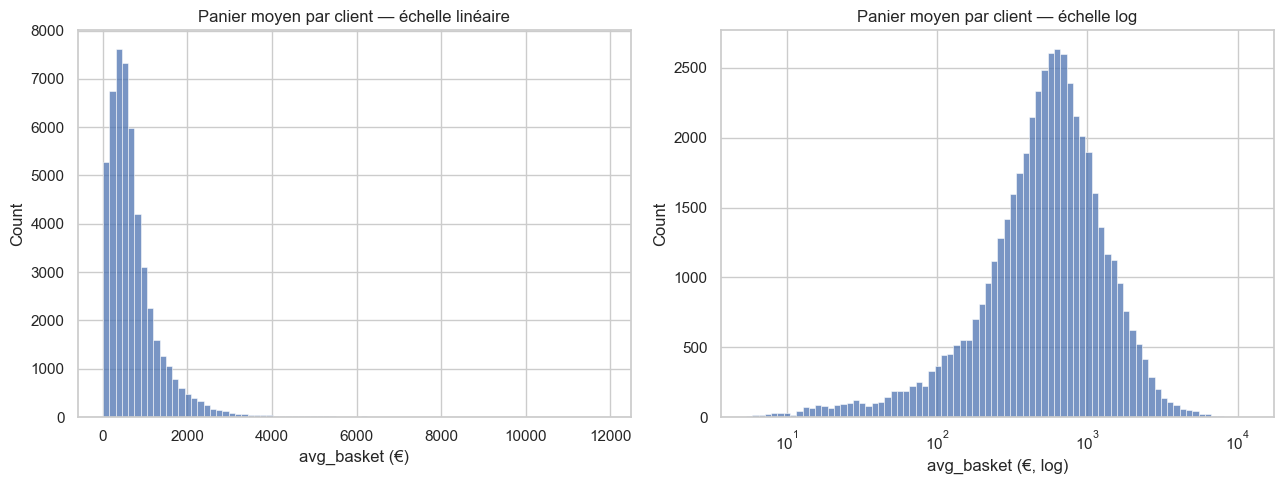

Clients avec un panier moyen > 2000€ : 2,248 (4.5 %) — probables comptes B2B / gros acheteurs


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.histplot(customers_clean['avg_basket'], bins=80, ax=axes[0])
axes[0].set_title("Panier moyen par client — échelle linéaire")
axes[0].set_xlabel("avg_basket (€)")

sns.histplot(customers_clean['avg_basket'], bins=80, log_scale=True, ax=axes[1])
axes[1].set_title("Panier moyen par client — échelle log")
axes[1].set_xlabel("avg_basket (€, log)")

plt.tight_layout()
plt.show()

b2b_threshold = 2000
n_b2b_like = (customers_clean['avg_basket'] > b2b_threshold).sum()
print(f"Clients avec un panier moyen > {b2b_threshold}€ : {n_b2b_like:,} "
      f"({n_b2b_like/len(customers_clean)*100:.1f} %) — probables comptes B2B / gros acheteurs")


La distribution est fortement asymétrique à droite (log-normale typique du retail) : la majorité des clients ont un panier moyen entre 50 € et 1 500 €, mais une queue fine (~4-5 % des clients) dépasse 2 000 € jusqu'à ~11 900 € — vraisemblablement des comptes professionnels/revendeurs plutôt que des particuliers. À garder à l'esprit pour ne pas laisser ces quelques comptes écraser les moyennes lors de la segmentation.


### Distribution de la fréquence d'achat

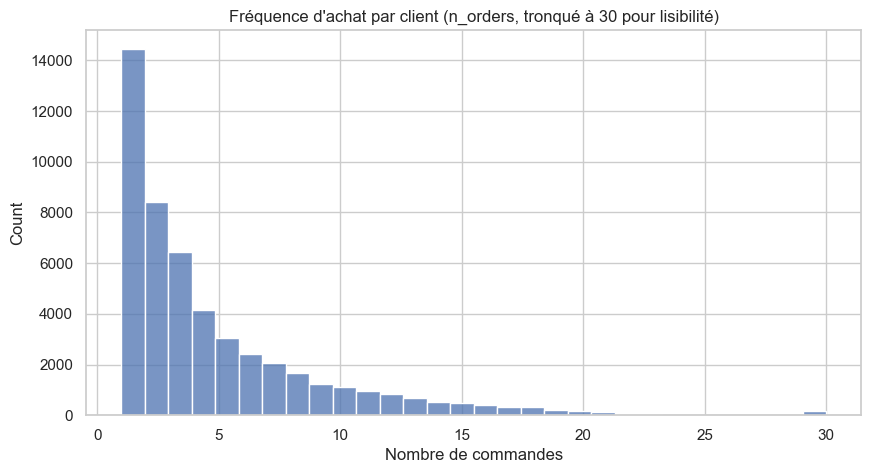

count   50,295.00
mean         4.59
std          5.88
min          1.00
50%          3.00
75%          6.00
90%         11.00
99%         20.00
max        373.00
Name: n_orders, dtype: float64


In [20]:
fig, ax = plt.subplots()
sns.histplot(customers_clean['n_orders'].clip(upper=30), bins=30, ax=ax)
ax.set_title("Fréquence d'achat par client (n_orders, tronqué à 30 pour lisibilité)")
ax.set_xlabel("Nombre de commandes")
plt.show()

print(customers_clean['n_orders'].describe(percentiles=[.5,.75,.9,.99]))


### Loi de Pareto : quelle part des clients génère 80 % du CA ?

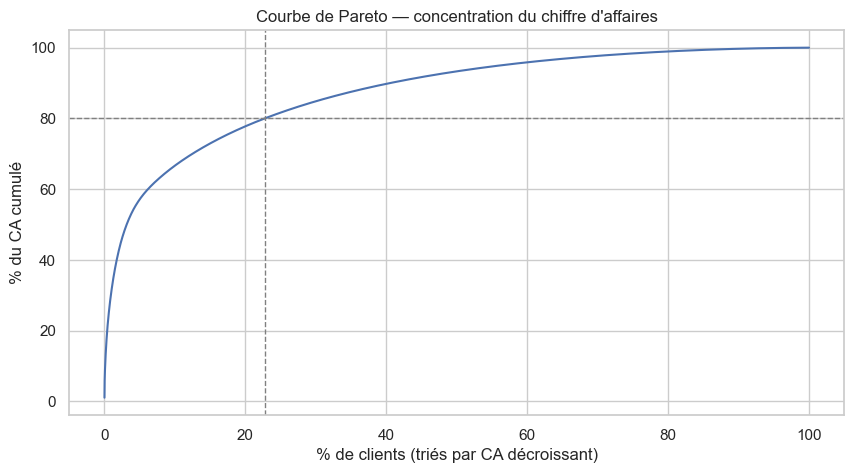

22.8 % des clients génèrent 80 % du chiffre d'affaires (11,199 / 49,213 clients).


In [21]:
rev_by_customer = sales.dropna(subset=['customer_id']).groupby('customer_id')['line_total'].sum().sort_values(ascending=False)

cum_share_customers = np.arange(1, len(rev_by_customer)+1) / len(rev_by_customer)
cum_share_revenue = rev_by_customer.cumsum() / rev_by_customer.sum()

n80 = (cum_share_revenue <= 0.8).sum() + 1
pct80 = n80 / len(rev_by_customer) * 100

fig, ax = plt.subplots()
ax.plot(cum_share_customers*100, cum_share_revenue*100)
ax.axhline(80, color='gray', linestyle='--', linewidth=1)
ax.axvline(pct80, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel("% de clients (triés par CA décroissant)")
ax.set_ylabel("% du CA cumulé")
ax.set_title("Courbe de Pareto — concentration du chiffre d'affaires")
plt.show()

print(f"{pct80:.1f} % des clients génèrent 80 % du chiffre d'affaires ({n80:,} / {len(rev_by_customer):,} clients).")


On est proche d'un vrai Pareto (~23 % des clients pour 80 % du CA, contre 20/80 en théorie) : la base est concentrée mais pas extrême. C'est un argument fort pour une segmentation qui isole ce noyau de clients à forte valeur.


### Saisonnalité — évolution du CA mensuel

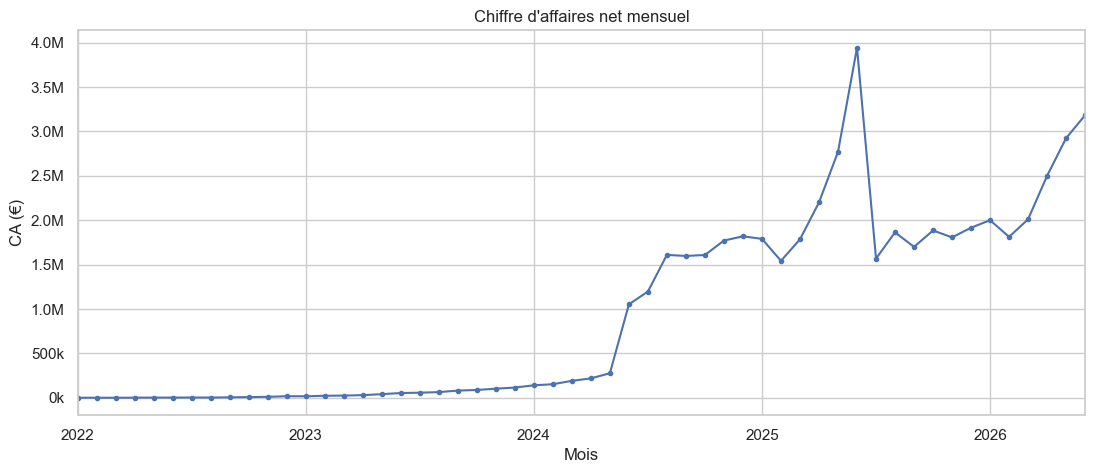

Top 5 mois (CA) :
invoice_date
2025-06-01   3,943,441.12
2026-06-01   3,184,095.13
2026-05-01   2,924,640.21
2025-05-01   2,770,437.16
2026-04-01   2,501,323.41
Name: line_total, dtype: float64


In [22]:
monthly_revenue = sales.set_index('invoice_date').resample('MS')['line_total'].sum()

fig, ax = plt.subplots(figsize=(13,5))
monthly_revenue.plot(ax=ax, marker='o', markersize=3)
ax.set_title("Chiffre d'affaires net mensuel")
ax.set_ylabel("CA (€)")
ax.set_xlabel("Mois")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}k"))
plt.show()

print("Top 5 mois (CA) :")
print(monthly_revenue.sort_values(ascending=False).head(5))


Deux phénomènes distincts se superposent, et il faut les découpler avant de parler de "saisonnalité" :

1. **Une croissance structurelle massive à partir de mi-2024** : le CA mensuel passe de ~270 k€ (mai 2024) à plus de 1 M€ (juin 2024) et reste depuis dans les millions. Ce n'est pas un pic saisonnier mais un changement d'échelle du business (croissance réelle de la base clients, ou historisation des transactions plus complète à partir de cette date — à vérifier auprès du data engineer).
2. **Un pic récurrent en mai-juin**, visible chaque année une fois le volume stabilisé (juin 2025 = pic absolu à 3,88 M€, puis chute de ~60 % en juillet 2025 ; le même schéma se répète en 2026 avec un CA croissant d'avril à juin). Ça ressemble à une saisonnalité "printemps/été" cohérente avec des produits cosmétiques (routines solaires, nouvelles collections, ou opérations commerciales type Fête des Mères).

**Implication marketing :** caler les campagnes d'acquisition/relance avant le pic d'avril-mai plutôt que pendant, et creuser pourquoi juillet chute aussi fort (rupture de stock ? fermeture estivale ? à vérifier avec le service commercial) avant de bâtir un calendrier de campagnes Jour 2.


### Géographie — répartition des clients par pays

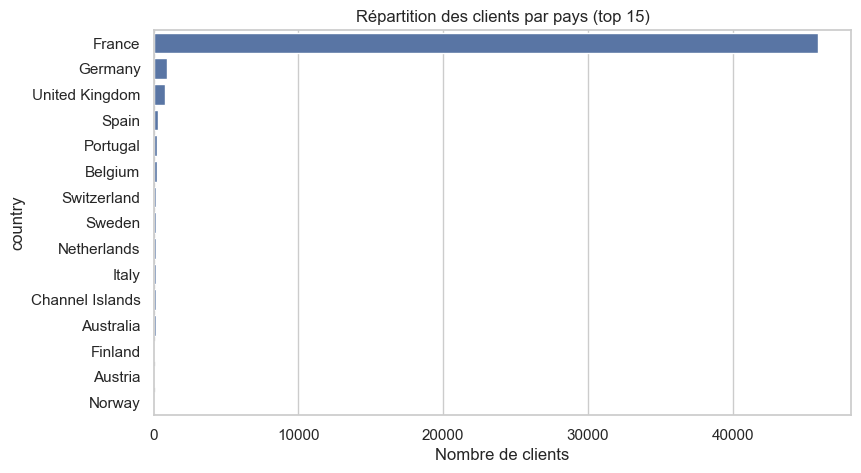

Part de la France dans la base clients : 91.3 %


Part de la France dans le CA net        : 92.1 %


In [23]:
top_countries = customers_clean['country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color=sns.color_palette()[0])
ax.set_xlabel("Nombre de clients")
ax.set_title("Répartition des clients par pays (top 15)")
plt.show()

france_share = customers_clean['country'].value_counts(normalize=True).iloc[0] * 100
print(f"Part de la France dans la base clients : {france_share:.1f} %")

revenue_by_country = sales.groupby('country')['line_total'].sum()
france_rev_share = revenue_by_country['France'] / revenue_by_country.sum() * 100
print(f"Part de la France dans le CA net        : {france_rev_share:.1f} %")


**Biais géographique confirmé** : la France représente environ 91 % des clients et un pourcentage quasi identique du chiffre d'affaires. Tous les autres pays (Allemagne, UK, Espagne, Portugal...) sont anecdotiques en volume.

> **Point de vigilance retenu** (comme indiqué dans l'énoncé) : toute segmentation construite demain sur cette base reflétera avant tout des comportements *français*. Les segments obtenus pour les autres pays reposeront sur des échantillons trop petits (quelques centaines de clients) pour être statistiquement robustes — à mentionner explicitement comme limite dans la présentation finale, avec recommandation de ne pas sur-interpréter les segments hors France.


### Le comportement d'achat varie-t-il selon la géographie ?

In [24]:
geo = (customers_clean[customers_clean['country'].isin(top_countries.index[:8])]
       .groupby('country')
       .agg(n_clients=('customer_id','count'),
            avg_basket=('avg_basket','mean'),
            n_orders_moyen=('n_orders','mean'))
       .sort_values('n_clients', ascending=False))
display(geo)


,n_clients,avg_basket,n_orders_moyen
country,,,
France,45904,714.26,4.61
Germany,918,806.84,5.03
United Kingdom,760,730.32,4.82
Spain,291,788.80,3.39
Portugal,211,845.20,3.58
Belgium,203,644.35,5.65
Switzerland,184,"1,414.67",3.97
Sweden,171,852.76,2.64


Sur les pays disposant d'un volume suffisant, le panier moyen (650-850 €) et la fréquence (3,4-5,6 commandes) restent dans des ordres de grandeur comparables à la France — pas de rupture de comportement flagrante, mais la taille d'échantillon hors France (quelques centaines de clients) invite à la prudence sur ces moyennes.


### Relations entre variables

**Récence vs montant dépensé**

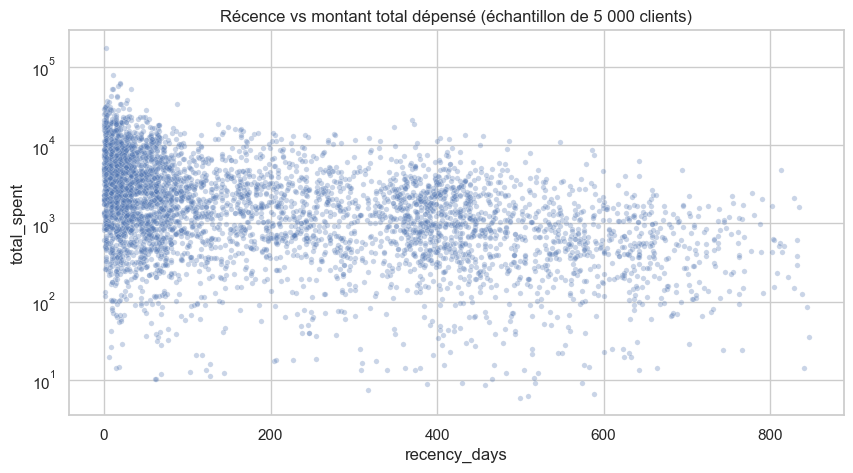

Corrélation de Pearson (linéaire)   : -0.271
Corrélation de Spearman (monotone)  : -0.449


In [25]:
fig, ax = plt.subplots()
sample = customers_clean.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='recency_days', y='total_spent', alpha=0.3, s=15, ax=ax)
ax.set_yscale('log')
ax.set_title("Récence vs montant total dépensé (échantillon de 5 000 clients)")
plt.show()

pearson = customers_clean['recency_days'].corr(customers_clean['total_spent'], method='pearson')
spearman = customers_clean['recency_days'].corr(customers_clean['total_spent'], method='spearman')
print(f"Corrélation de Pearson (linéaire)   : {pearson:.3f}")
print(f"Corrélation de Spearman (monotone)  : {spearman:.3f}")


La relation n'est **pas linéaire** (Pearson = -0,27) mais bien plus marquée en monotone (Spearman = -0,45) : les clients récemment actifs ont *tendanciellement* plus dépensé, mais avec beaucoup de dispersion et probablement un effet de seuil plutôt qu'une droite — cohérent avec la nature même du calcul (`recency_days` dépend de `last_purchase`, donc un client actif depuis longtemps mais inactif récemment peut quand même avoir un `total_spent` élevé).


**Fréquence vs panier moyen : les clients fréquents dépensent-ils plus par visite ?**

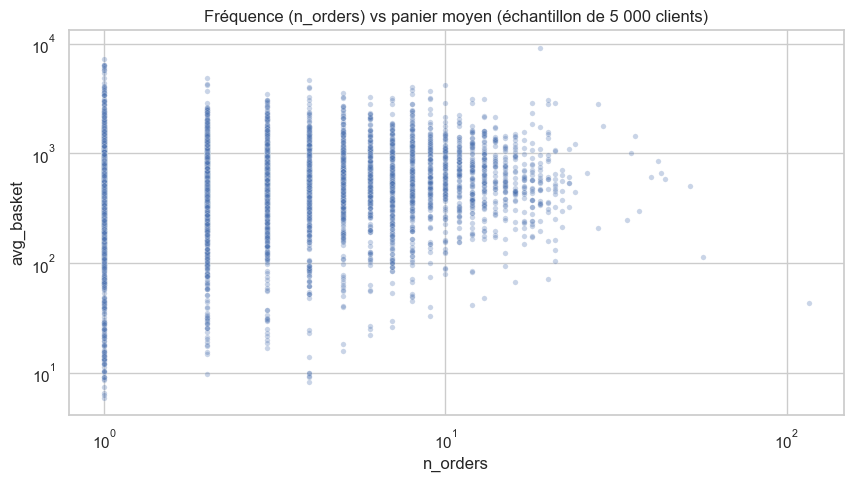

Corrélation de Spearman fréquence / panier moyen : 0.093


In [26]:
fig, ax = plt.subplots()
sample2 = customers_clean.sample(5000, random_state=42)
sns.scatterplot(data=sample2, x='n_orders', y='avg_basket', alpha=0.3, s=15, ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Fréquence (n_orders) vs panier moyen (échantillon de 5 000 clients)")
plt.show()

spearman_freq_basket = customers_clean['n_orders'].corr(customers_clean['avg_basket'], method='spearman')
print(f"Corrélation de Spearman fréquence / panier moyen : {spearman_freq_basket:.3f}")


**Non**, la corrélation est quasi nulle (Spearman ≈ 0,09) : acheter souvent et dépenser beaucoup par panier sont **deux dimensions indépendantes**. On distingue déjà à l'œil au moins deux profils "naturels" dans le nuage de points : des clients à fréquence élevée / panier modeste (habitués, petits achats répétés) et des clients à fréquence faible / panier élevé (achats ponctuels importants, probablement une partie des comptes B2B repérés plus haut). C'est exactement le genre de structure qu'une segmentation RFM devra capturer en Jour 2 plutôt qu'un score unique de "valeur client".


### Catégories de produits

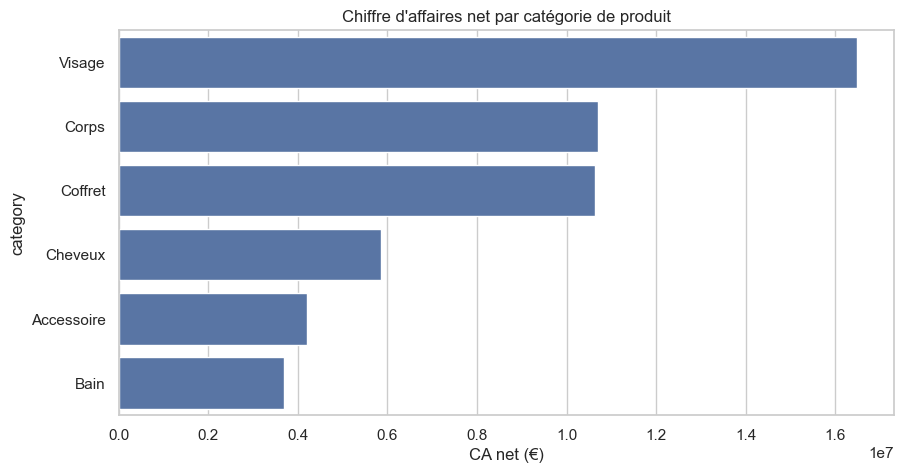

,CA (€),Part (%)
category,,
Visage,"16,481,846.04",32.00
Corps,"10,708,936.46",20.80
Coffret,"10,643,406.52",20.60
Cheveux,"5,864,766.38",11.40
Accessoire,"4,199,061.87",8.10
Bain,"3,681,630.78",7.10


In [27]:
cat_revenue = sales.groupby('category')['line_total'].sum().sort_values(ascending=False)
cat_share = (cat_revenue / cat_revenue.sum() * 100).round(1)

fig, ax = plt.subplots()
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, ax=ax, color=sns.color_palette()[0])
ax.set_xlabel("CA net (€)")
ax.set_title("Chiffre d'affaires net par catégorie de produit")
plt.show()

display(pd.DataFrame({'CA (€)': cat_revenue, 'Part (%)': cat_share}))


La répartition est **plutôt équilibrée**, sans monopole : Visage domine (32 %) mais reste loin d'une position écrasante, suivi de près par Corps et Coffret (~21 % chacun), puis Cheveux (11 %), Accessoire (8 %) et Bain (7 %). Ce point de comparaison servira en Jour 2 à vérifier si certains segments RFM ont une affinité produit marquée (ex. les gros comptes achètent-ils surtout des Coffrets ?).


### Données zero-party (`customers.csv`)

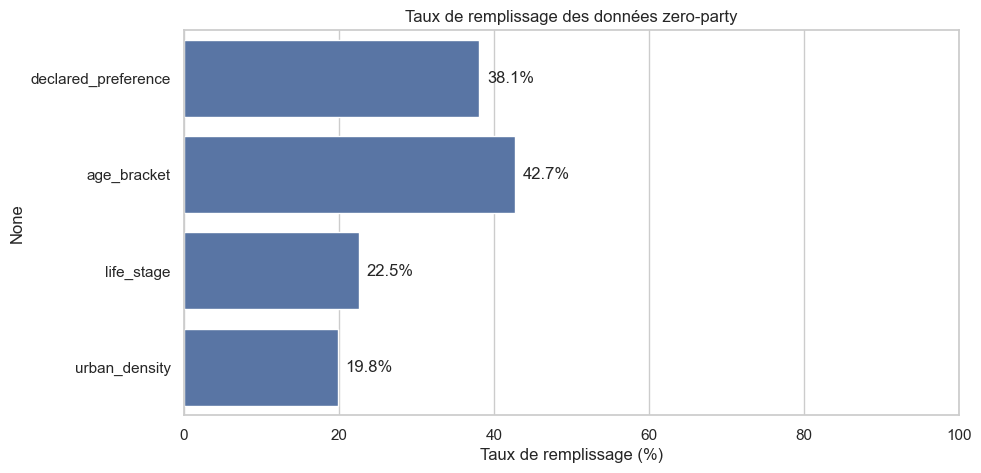

declared_preference   38.10
age_bracket           42.70
life_stage            22.50
urban_density         19.80
dtype: float64


In [28]:
zero_party_cols = ['declared_preference','age_bracket','life_stage','urban_density']
fill_rates = (customers_clean[zero_party_cols].notna().mean()*100).round(1)

fig, ax = plt.subplots()
sns.barplot(x=fill_rates.values, y=fill_rates.index, ax=ax, color=sns.color_palette()[0])
ax.set_xlabel("Taux de remplissage (%)")
ax.set_xlim(0,100)
ax.set_title("Taux de remplissage des données zero-party")
for i, v in enumerate(fill_rates.values):
    ax.text(v+1, i, f"{v}%", va='center')
plt.show()
print(fill_rates)


Des taux de remplissage partiels sont **attendus et normaux pour du zero-party** (déclaratif, opt-in — on ne force jamais un client à répondre). Ce qui est plus notable, c'est l'**écart entre les quatre colonnes** : `declared_preference` (38 %) et `age_bracket` (43 %) sont deux à trois fois mieux renseignées que `life_stage` (22 %) et `urban_density` (20 %). Cela suggère que ces champs ne sont **pas collectés via le même point de contact** (ex. préférence produit demandée à la commande, vs. urbanité/situation familiale demandées seulement dans un questionnaire optionnel plus rarement complété) — à vérifier avec l'équipe CRM, et à garder en tête : toute segmentation qui s'appuierait sur `life_stage` ou `urban_density` ne couvrira qu'1 client sur 5.


## Étape 4 — Hypothèses marketing

Sur la base de l'EDA ci-dessus, voici les hypothèses à valider/invalider avec la segmentation RFM du Jour 2 :

1. *Je suppose que* la forte concentration du CA (23 % des clients pour 80 % du CA) *implique* l'existence d'un segment "Top clients" à haute valeur nettement distinct du reste de la base, *ce qui suggère* un programme de fidélisation/VIP dédié (accès prioritaire, service personnalisé) plutôt qu'une communication uniforme.

2. *Je suppose que* l'absence de corrélation entre fréquence d'achat et panier moyen (Spearman ≈ 0,09) *implique* qu'il existe au moins deux populations de bons clients aux logiques opposées — acheteurs réguliers à petits paniers vs. acheteurs occasionnels à gros paniers (B2B) — *ce qui suggère* deux stratégies marketing distinctes : programme de fréquence/abonnement pour les premiers, offres évènementielles à forte valeur perçue pour les seconds.

3. *Je suppose que* le pic de CA récurrent en mai-juin suivi d'une chute marquée en juillet *implique* une fenêtre d'achat saisonnière concentrée (routine solaire / nouvelles collections), *ce qui suggère* de concentrer les campagnes d'acquisition et de relance sur mars-mai plutôt qu'en pleine saison, et d'investiguer une action spécifique (relance email, promo) pour limiter la chute de juillet.

4. *Je suppose que* la surreprésentation de la France (91 % des clients et du CA) *implique* que les segments RFM du Jour 2 seront calibrés sur un comportement essentiellement français, *ce qui suggère* soit d'exclure les pays à faible échantillon de la segmentation fine, soit de les regrouper en un segment "International" traité à part plutôt que de leur appliquer les mêmes seuils.

5. *Je suppose que* le faible taux de remplissage et l'hétérogénéité des données zero-party (20 à 43 % selon les champs) *implique* qu'on ne peut pas s'appuyer sur elles comme variable principale de segmentation, *ce qui suggère* de les traiter comme un enrichissement optionnel d'un segment RFM déjà défini (ex. "quel âge déclaré domine dans le segment Top clients ?") plutôt que comme un axe de segmentation à part entière.


---
## Récapitulatif des jeux de données nettoyés

- `transactions_clean` : `transactions_raw` moins 445 doublons exacts et 6 lignes d'ajustement comptable (préfixe `A`), enrichi de 5 flags (`has_customer`, `is_cancellation`, `is_return`, `is_fee`, `is_zero_price`) et de `line_total`. Rien d'autre n'a été supprimé — les anomalies sont **documentées et flaguées**, pas effacées, pour rester analysables selon le besoin (CA global vs. CA par client vs. analyse produit).
- `customers_clean` : `customers_raw` avec les dates converties en `datetime`. Aucune ligne supprimée (aucune incohérence de date, aucun doublon, aucune valeur négative). Ses colonnes agrégées (`total_spent`, `n_orders`, `avg_basket`, `recency_days`) sont à traiter comme indicatives — le RFM du Jour 2 sera recalculé depuis `transactions_clean`.
